# Windstorm tracks and footprints derived from reanalysis over Europe between 1940 to present: Algorithm comparison

Production date: 2026-MM-DD

**Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch.**

Produced by: Enis Gerxhalija & Olivier Burggraaff (National Physical Laboratory).

## 🌍 Use case: Use case listed here in full 

## ❓ Quality assessment question
* **How do the TempestExtremes (MSLP) and Hodges (vorticity) tracking algorithms differ in their detection of extratropical cyclones, particularly in terms of their sensitivity, duration, and intensity?**

**‘Context paragraph’ (no title/heading)** - a very short introduction before the assessment statement describing approach taken to answer the user question. One or two key references could be useful, if the assessment summarises literature.

**Background**

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* Finding 1
* Finding 2
* Finding 3
* etc
```

## 📋 Methodology

**Note:** This notebook is currently just a brain-dump in anticipation of starting the actual quality assessment at a later stage.

**Summary**  

The analysis and results are organised in the following steps, which are detailed in the sections below:

**[](section-setup)**

**[](section-download)**

**[](section-sensitivity)**

**[](section-duration)**

**[](section-intensity)**

Any further notes on the method could go here (explanations, caveats or limitations).

## 📈 Analysis and results

(section-setup)=
### 1. Code setup
```{note}
This notebook uses [earthkit](https://github.com/ecmwf/earthkit) for
downloading ([earthkit-data](https://github.com/ecmwf/earthkit-data))
and visualising ([earthkit-plots](https://github.com/ecmwf/earthkit-plots)) data.
Because earthkit is in active development, some functionality may change after this notebook is published.
If any part of the code stops functioning, please raise an issue on our GitHub repository so it can be fixed.
```

#### Imports

In [29]:
# Input / Output
from pathlib import Path
import earthkit.data as ekd
import warnings

# General data handling
import numpy as np
np.seterr(divide="ignore")  # Ignore divide-by-zero warnings
import pandas as pd
import geopandas as gpd
from functools import partial, reduce
from operator import and_ as bitwise_and
from dask.array.core import PerformanceWarning
warnings.simplefilter(action="ignore", category=PerformanceWarning)

# Visualisation
import earthkit.plots as ekp
from earthkit.plots.styles import Style
import matplotlib.pyplot as plt
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams["figure.labelweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
from matplotlib.colors import LogNorm
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import cartopy
from cartopy import crs as ccrs
import shapely
from shapely.geometry import Polygon, MultiPolygon
import cmcrameri as cmc
from tqdm import tqdm  # Progress bars
import matplotlib.colors as mcolors
# Visualisation in Jupyter book -- automatically ignored otherwise
try:
    from myst_nb import glue
except ImportError:
    glue = None

# Type hints
from typing import Callable, Iterable, Optional
from cartopy.mpl.geoaxes import GeoAxes


#### Helper functions

##### Data (pre-)processing

The following cell contains some pre-defined constants for convenience,
such as a list of variable names in the data:

In [30]:
# Data
TRACKING_ALGORITHMS = ["hodges", "tempest_extremes"]
NUTS_LEVELS         = [0, 1, 2]

# Columns in data
SELECTION_COLUMNS   = ["algorithm", "threshold", "year",]
VARIABLES           = ["storms_number", "mean_wind_gust", "ssi", "normalised_ssi", "area_ratio", "wind_gust_ratio",]
NUTS_VARIABLES      = ["region", "country_code", "NUTS_level", "NUTS_name",]

# Organisation of data
INDEX_COLUMNS       = ["algorithm", "threshold", "region", "year",]

The following functions select data from a (Geo)DataFrame according to one or multiple conditions,
e.g. a specific year and tracking algorithm:

In [31]:
def _select_from_column(df: pd.DataFrame, col: str, val) -> pd.Series:
    """
    Create a True/False mask for one column `col` in a (Geo)DataFrame `df`
    where the value is `val`.
    Checks for iterable/non-iterable values and switches between .isin and == accordingly.
    """
    # Check for single / multiple values
    if df[col].dtype == "O":  # String column
        if isinstance(val, str):
            # Value is str -> Single value
            iterable_val = False
        elif isinstance(val, Iterable):
            # Value is Iterable but not str -> assume Iterable[str]
            iterable_val = True
        else:
            raise ValueError(f"Cannot parse value of type `{type(val)}` for column `{col}`.")
    else:  # Non-string column, assume number or similar
        iterable_val = isinstance(val, Iterable)

    # Create True/False mask
    selection = (df[col].isin(val)) if iterable_val else (df[col] == val)
    return selection

def select_data(df: pd.DataFrame, **kwargs):
    """
    Select data from a given (Geo)DataFrame `df` according to any number of conditions,
    matching its column names.
    """
    # Create masks for all col/val pairs in kwargs, then combine with & (bitwise and)
    selection_all = [_select_from_column(df, col, val) for col, val in kwargs.items()]
    selection = reduce(bitwise_and, selection_all)

    # Apply and return
    df_selection = df[selection]
    return df_selection

The following functions allow large amounts of data to be downloaded from CDS, and to send requests based on track information.

In [32]:
# Handling CDS size limits
def batch_requests(main_request: dict, *, batch_key: str="year", n: int=20) -> list[dict]:
    """ Take a big request (e.g. ERA5–Drought for all years) and separate it into smaller ones (size `n`). """
    from itertools import batched
    full_range = main_request[batch_key]  # e.g. [1940, 1941, ..., 2024]
    batched_range = batched(full_range, n)  # e.g. [1940, ..., 1959], [1960, ..., 1979], ...
    subrequests = [main_request | {batch_key: batch} for batch in batched_range]  # create corresponding CDS requests
    return subrequests
    
def build_era5msl_request_from_time(time_value):
    """
    Create a CDS API request for ERA5 MSLP for the given date.
    Always retrieves the 4 synoptic times.
    """
    
    # Ensure datetime
    time_value = pd.to_datetime(time_value)

    year = f"{time_value.year}"
    month = f"{time_value.month:02d}"
    day = f"{time_value.day:02d}"

    request = {
        "product_type": ["reanalysis"],
        "variable": ["mean_sea_level_pressure"],
        "year": [year],
        "month": [month],
        "day": [day],
        "time": ["00:00", "06:00", "12:00", "18:00"],
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [70, -80, 30, 35],  # windstorm track domain
    }

    return request

##### Visualisation

In [33]:
# Geometry / Projection
EPSG = 3035
CRS = cartopy.crs.epsg(EPSG)
MAP_KWARGS={"projection": CRS,
            "xlim": (0.25e7, 0.74e7), "ylim": (1.3e6, 5.5e6),  # Continental Europe
           }

# Define styles for land, borders, etc.
STYLE_LAND            = {"zorder": 1, "facecolor": "#ccced1", "edgecolor": "none"}
STYLE_COASTLINE       = {"zorder": 3, "edgecolor": "black", "linewidth": 1}
STYLE_NATIONAL_BORDER = {"zorder": 3, "edgecolor": "black", "linewidth": 0.5}
STYLE_CHOROPLETH      = {"zorder": 2, "edgecolor": STYLE_NATIONAL_BORDER["edgecolor"], "linewidth": STYLE_NATIONAL_BORDER["linewidth"]/5}

In [34]:
_style_footprint = {"cmap": plt.cm.cividis, "vmin": 0, "vmax": 40}

styles = {
    "footprint": Style(**_style_footprint),
}

# Apply general settings
for style in styles.values():
    style.normalize = False

In [35]:
def _glue_or_show(fig: plt.Figure, glue_label: Optional[str]=None) -> None:
    """
    If `glue` is available, glue the figure using the provided label.
    If not, display the figure in the notebook.
    """
    try:
        glue(glue_label, fig, display=False)
    except TypeError:
        plt.show()
    finally:
        plt.close()

def _add_textbox_to_subplots(text: str, *axs: Iterable[plt.Axes | ekp.Subplot], right=False) -> None:
    """ Add a text box to each of the specified subplots. """
    # Get the plt.Axes for each ekp.Subplot
    axs = [subplot.ax if isinstance(subplot, ekp.Subplot) else subplot for subplot in axs]

    # Set up location
    x = 0.95 if right else 0.05
    horizontalalignment = "right" if right else "left"

    # Add the text
    for ax in axs:
        ax.text(x, 0.95, text, transform=ax.transAxes,
        horizontalalignment=horizontalalignment, verticalalignment="top",
        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "round",
              "alpha": 1})

In [36]:
def decorate_fig(fig: ekp.Figure, *, title: Optional[str]="") -> None:
    """ Decorate an earthkit figure with land, coastlines, etc. """
    # Add progress bar because individual steps can be very slow for large plots
    with tqdm(total=4, desc="Decorating", leave=False) as progressbar:
        fig.land()
        progressbar.update()
        fig.coastlines()
        progressbar.update()
        # fig.borders()
        # progressbar.update()
        fig.gridlines(linestyle=plt.rcParams["grid.linestyle"])
        progressbar.update()
        fig.title(title)
        progressbar.update()

def decorate_fig(axs: Iterable[GeoAxes], *, title: Optional[str]="") -> None:
    """ Decorate a cartopy/matplotlib figure with land, coastlines, etc. """
    # Will be replaced by preceding (earthkit) function when earthkit-plots supports choropleth maps
    try:  # Ravel if numpy array
        axs = axs.ravel()
    except AttributeError:
        pass

    # Apply each decoration in order
    for ax in axs:
        ax.add_feature(cartopy.feature.LAND,      **STYLE_LAND)
        ax.add_feature(cartopy.feature.COASTLINE, **STYLE_COASTLINE)
        ax.add_feature(cartopy.feature.BORDERS,   **STYLE_NATIONAL_BORDER)

In [37]:
def plot_storm_counts(yearly_nuts_mean):
    
    # Get available thresholds
    thresholds = yearly_nuts_mean[0].index.get_level_values("threshold").unique()

    fig, axes = plt.subplots(2, 2, sharex=True)
    axes = axes.ravel()  
    
    for ax, thr in zip(axes, thresholds):
        df = yearly_nuts_mean[0]["storms_number"]
        
        # Extract time series
        hodges = df.loc["hodges", thr]
        tempest = df.loc["tempest_extremes", thr]
        
        # Plot
        hodges.plot(ax=ax, label="Hodges", linewidth=2)
        tempest.plot(ax=ax, label="TempestExtremes", linewidth=2, linestyle="--")
        
        # Styling
        ax.set_title(f"Threshold = {thr}")
        ax.set_ylabel("Storm count")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # Shared x-axis label
    axes[-1].set_xlabel("Year")

    plt.suptitle("Storm Count Comparison (summed over NUTS0)", fontsize=14)
    plt.show()

def plot_nuts_greater_eq_than_spatial(nuts, column = "percentage" , label = "% years",
                       title = "% years where Δ #(Hodges - TempestExtremes) > 0",
                       vmin = 0, vmax = 100, cmap = "RdBu_r" ):

    
    chart = ekp.Map(domain=[-30, 50, 20, 85], crs=ccrs.PlateCarree())

    ax = chart.ax 

    bounds = list(range(0, 110, 10))
    norm = mcolors.BoundaryNorm(bounds, ncolors=plt.get_cmap(cmap).N)

    nuts.plot(
        column=column,
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm = norm,
        legend=True,
        edgecolor="black",
        vmin=vmin,          
        vmax=vmax,

        linewidth=0.3,
        legend_kwds={"label": f"{label}"},
    )

    chart.coastlines()
    chart.borders()
    ax.set_title(title)

    chart.show()

##### Track analysis

In [38]:
def get_track_ends(df):
    """
    Generate a summary dataset of cyclone tracks by extracting start and end properties.
    """
    
    records = []  # will store one summary row per track

    # Loop over each algorithm (first level of MultiIndex)
    for algo, df_algo in df.groupby(level="algorithm"):

        # Within each algorithm, loop over individual tracks (by id)
        for track_id, group in df_algo.groupby(level="id"):

            # Ensure track points are in chronological order
            group = group.sort_values("time")

            # Extract first and last points of the track
            start = group.iloc[0]
            end   = group.iloc[-1]

            # Build a summary record for this track
            records.append({
                "algorithm": algo,          # which tracking algorithm
                "id": track_id,             # track identifier

                # start point info
                "start_time": start["time"],
                "start_lat":  start["latitude"],
                "start_lon":  start["longitude"],

                # end point info
                "end_time":   end["time"],
                "end_lat":    end["latitude"],
                "end_lon":    end["longitude"],

                # intensity metric across the track
                "mean_fg10": group["fg10"].max(),  # actually max, not mean
                # "mean_fg10": group["fg10"].mean()  # alternative option
            })

    # Return everything as a DataFrame (one row per track)
    return pd.DataFrame(records)


def track_stats(tracks_start_end):

    """
    Generate a statistical dataset of cyclone tracks by taking start and end properties,
    and calculating their mean duration over whole year, winter season and summer season.
    """

    # Define seasonal groupings (by start month)
    winter_months = [12, 1, 2]
    summer_months = [6, 7, 8]

    # Compute track duration (in whole days)
    tracks_start_end["duration (days)"] = (
        tracks_start_end["end_time"] - tracks_start_end["start_time"]
    ).dt.days

    # Compute mean statistics across all tracks for each algorithm
    mean_track = tracks_start_end.groupby("algorithm").mean(numeric_only=True)

    # Filter tracks that start in winter months and compute means
    tracks_winter = tracks_start_end[
        tracks_start_end["start_time"].dt.month.isin(winter_months)
    ]
    mean_track_winter = tracks_winter.groupby("algorithm").mean(numeric_only=True)

    # Filter tracks that start in summer months and compute means
    tracks_summer = tracks_start_end[
        tracks_start_end["start_time"].dt.month.isin(summer_months)
    ]
    mean_track_summer = tracks_summer.groupby("algorithm").mean(numeric_only=True)

    # Return all three summary tables
    return mean_track, mean_track_winter, mean_track_summer


Functions used to match tracks by overlapping timestamps and mean distance between overlapping points.

In [39]:
def match_by_time(data, TRACKING_ALGORITHMS = ["hodges", "tempest_extremes"]):
    
    df1, df2 = [data.loc[alg] for alg in TRACKING_ALGORITHMS]

    # bring `id` out of the index into a column
    df1 = df1.reset_index(level="id").rename(columns={"id": "id_hodges"})
    df2 = df2.reset_index(level="id").rename(columns={"id": "id_tempest_extremes"})

    # Find where times overlap
    time_overlap = pd.merge(df1, df2, on="time", how="inner", suffixes=[f"_{alg}" for alg in TRACKING_ALGORITHMS])
    
    overlap_counts = (
        time_overlap.groupby(["id_hodges", "id_tempest_extremes"])["time"]
        .nunique()
    ) # count number of overlapping time points.
    
    results = []
    
    for (hodges_id, tempest_id), overlap_points in overlap_counts.items(): # return key and value
    
        hodges_points = data.xs(
            ("hodges", hodges_id), level=("algorithm", "id")
        )["time"].nunique() # how many points in the tracked storm for id.
    
        tempest_points = data.xs(
            ("tempest_extremes", tempest_id), level=("algorithm", "id")
        )["time"].nunique() # how many points in the tracked storm for id.
    
        mean_points = (hodges_points + tempest_points) / 2 # mean points between paired storms.
    
        time_match = overlap_points / mean_points # number of points overlapped between paired storm.
    
        match_true = time_match > 0.6 # condition for time overlap
    
        results.append({
            "hodges_id": hodges_id,
            "tempest_id": tempest_id,
            "overlap_points": overlap_points,
            "hodges_points": hodges_points,
            "tempest_points": tempest_points,
            "time_match": time_match,
            "match": match_true
        })
    
    results_df = pd.DataFrame(results)
    
    time_matches_only = results_df[results_df["match"]] # only keep the matches

    return time_matches_only 

def match_by_mean_distance(data, time_matches_only):

    hodges = data.loc["hodges"]
    tempest = data.loc["tempest_extremes"]
    
    for hodges_id, tempest_id in zip(time_matches_only["hodges_id"], time_matches_only["tempest_id"]):
    
        import haversine as hs   
        from haversine import Unit
                                
        distances = []

        # extract tracks
        h_track = hodges.loc[hodges_id]
        t_track = tempest.loc[tempest_id]

        # align on common timestamps
        common_times = h_track.index.intersection(t_track.index) # return timestamps
    
        for t in common_times:

            print(common_times)
            h = h_track.loc[t]
            te = t_track.loc[t]

            distances.append(
                hs.haversine(
                    (h["latitude"], h["longitude"]),
                    (te["latitude"], te["longitude"]),
                    unit=Unit.KILOMETERS
                )
            )

        if distances:
            time_matches_only.loc[
                (time_matches_only["hodges_id"] == hodges_id) &
                (time_matches_only["tempest_id"] == tempest_id),
                "distance"
            ] = np.mean(distances)

    return time_matches_only

Functions used to analyse sensitivity of storm indicator download.

In [40]:
def filter_storms_per_season(data, winter_months = [12, 1, 2], summer_months = [6, 7, 8]):

    data_copy = data.copy()
    
    # Extract month
    data_copy["month"] = data_copy["time"].dt.month
    
    # Winter: Dec (12), Jan (1), Feb (2)
    winter_storms = data_copy[data_copy["month"].isin(winter_months)]
    
    # Summer: Jun (6), Jul (7), Aug (8)
    summer_storms = data_copy[data_copy["month"].isin(summer_months)]

    return winter_storms, summer_storms

def count_storms_per_month(data, algorithm):
    subset = data.loc[algorithm].copy()
    subset["month"] = subset["time"].dt.month
    subset["storm_id"] = subset.index.get_level_values("id")
    return subset.groupby("month")["storm_id"].nunique()

def compute_fractions(count, reference):
    winter_months = [12, 1, 2]
    summer_months = [6, 7, 8]
    winter = count.loc[winter_months].sum() / reference.loc[winter_months].sum()
    summer = count.loc[summer_months].sum() / reference.loc[summer_months].sum()
    count_ratio =  count.loc[summer_months].sum() / count.loc[winter_months].sum() 
    ref_ratio = reference.loc[summer_months].sum() /  reference.loc[winter_months].sum()
    return winter, summer, count_ratio, ref_ratio

Functions used to spatially analyse sensitivity of storm indicator download in NUTS region.

In [41]:
def compute_mean_by_nuts(data, value_column, nuts_levels=(0, 1, 2)):
    """
    Compute mean values grouped by (algorithm, threshold) for each NUTS level.
    """
    # Take mean across years (frequency).
    data_grouped = (
        data[[value_column, "NUTS_level"]]
        .groupby(level=("algorithm", "threshold", "region"))
        .mean(numeric_only=True)
    )

    # Split by NUTS level
    nuts_groups = {
        level: data_grouped.loc[data_grouped["NUTS_level"] == level]
        for level in nuts_levels
    }

    # Take mean across entire domain
    result = {
        level: df.groupby(level=("algorithm", "threshold")).mean(numeric_only=True)
        for level, df in nuts_groups.items()
    }

    return result

def computer_percentage_greater_eq(data, nuts_gdf, value_column="mean_wind_gust",
    threshold=0, levels=(0, 1, 2)):
    
    
    hodges_greater = data[value_column].loc["hodges"] >= data[value_column].loc["tempest_extremes"]

    percentage = (
        hodges_greater
        .groupby(level=("threshold", "region"))
        .mean() * 100
    )

    percentage = percentage.loc[threshold].reset_index(name="percentage")
    
    map_df = nuts_gdf.merge(
        percentage,
        left_on="region",
        right_on="region",
        how="left",
    )
    
    map_df = map_df.to_crs(epsg=4326)
    
    nuts_maps = {
            level: map_df[map_df["LEVL_CODE"] == level]
            for level in levels
        }

    return nuts_maps

def compute_yearly_nuts_aggregation(
    data,
    value_column,
    nuts_levels=(0, 1, 2),
    agg_func="sum",
):
    """
    Compute yearly aggregation per NUTS level.
    """

    # Split by NUTS level
    yearly_nuts_groups = {
        level: data.loc[data["NUTS_level"] == level]
        for level in nuts_levels
    }

    # Aggregate across domain (per year)
    if agg_func == "sum":
        yearly_nuts_agg = {
            level: df.groupby(level=("algorithm", "threshold", "year")).sum(numeric_only=True)
            for level, df in yearly_nuts_groups.items()
        }
    elif agg_func == "mean":
        yearly_nuts_agg = {
            level: df.groupby(level=("algorithm", "threshold", "year")).mean(numeric_only=True)
            for level, df in yearly_nuts_groups.items()
        }
    else:
        raise ValueError("agg_func must be 'sum' or 'mean'")

    return yearly_nuts_agg

(section-download)=
### 2. Download

In [42]:
domain_tracks = ekp.geo.domains.Domain.from_bbox([-80, 35, 5, 70], name="Europe")
domain_footprints = ekp.geo.domains.Domain.from_bbox([-25, 35, 30, 70], name="Europe")

In [43]:
dataset = "sis-european-wind-storm-reanalysis"

#### Windstorm track download 

In [44]:
tracking_algorithms = ["hodges", "tempestextremes"]

request_variables = {
    "variable": "all",
    "tracking_algorithm": tracking_algorithms,
}

request_time = {
    "year": [f"{year}" for year in range(1940, 2025)],
    "month": [f"{month:02}" for month in range(1, 13)],
    "day": [f"{day:02}" for day in range(1, 32)],
}

request = {
    "product": "windstorm_track",
    "event_aggregation": "single_event",
} | request_variables | request_time

track_data = ekd.from_source("cds", dataset, request)
track_data = track_data.to_pandas()
track_data["time"] = pd.to_datetime(track_data["time"])
track_data = track_data.set_index(["algorithm", "id"]) # Reindex
track_data

time  latitude  longitude       fg10  \
algorithm        id                                                        
hodges           1   1940-02-22 00:00:00     63.25     -24.00  10.452867   
                 1   1940-02-22 06:00:00     63.50     -25.00  12.599429   
                 1   1940-02-22 12:00:00     62.75     -11.25   5.919555   
                 1   1940-02-22 18:00:00     63.00     -12.00   7.741296   
                 1   1940-02-23 00:00:00     62.75     -12.25   4.190840   
...                                  ...       ...        ...        ...   
tempest_extremes 863 2024-12-31 06:00:00     57.50     -16.50  16.137968   
                 863 2024-12-31 12:00:00     58.25      -8.75  11.453899   
                 863 2024-12-31 18:00:00     58.50      -4.50  12.863035   
                 863 2025-01-01 00:00:00     59.50       5.00   6.073773   
                 863 2025-01-01 06:00:00     59.00       7.00  10.901903   

                           lsm        msl  
algorithm        id                        
hodges           1    0.000000  98962.875  
                 1    0.000000  98905.190  
                 1    0.000000  98809.125  
                 1    0.000000  98755.560  
                 1    0.000000  98655.310  
...                        ...        ...  
tempest_extremes 863  0.000000  98331.500  
                 863  0.000000  98653.060  
                 863  0.513747  98624.750  
                 863  0.206189  98624.120  
                 863  0.919080  98635.750  

[33878 rows x 6 columns]

#### Windstorm summary indicators
We download the full windstorm summary indicator table from the
[sis-european-wind-storm-reanalysis](https://doi.org/10.24381/bf1f06a9)
CDS entry.
Because this is a simple table,
the data are loaded into a Pandas [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
Geographical information will be added to this table in the next subsection.

In [45]:
request = {
    "product": "windstorm_summary_indicator",
    # Note that we do not use the TRACKING_ALGORITHMS constant here because the CDS
    # does not have an _ in `tempestextremes` but the resulting table does.
} | request_variables

indic_data = ekd.from_source("cds", dataset, request)
indic_data = indic_data.to_pandas()
indic_data

,year,region,threshold,storms_number,mean_wind_gust,ssi,normalised_ssi,area_ratio,wind_gust_ratio,algorithm
0,1940,FR,0.0,10,19.450012,3.954249e+09,0.292018,0.980225,0.667874,hodges
1,1940,FR,15.6,10,21.074094,5.029804e+09,0.371447,0.980225,0.723641,hodges
2,1940,FR,20.0,9,23.179559,6.692985e+09,0.494271,0.980225,0.795939,hodges
3,1940,FR,25.0,5,26.403130,9.891692e+09,0.730493,0.980225,0.906630,hodges
4,1940,HR,0.0,2,13.676930,1.374967e+08,0.243874,0.959770,0.633382,hodges
...,...,...,...,...,...,...,...,...,...,...
341243,2025,NO07,25.0,2,28.244418,2.161430e+09,1.543523,1.000000,1.155680,tempest_extremes
341244,2025,NO0B,0.0,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes
341245,2025,NO0B,15.6,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes
341246,2025,NO0B,20.0,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes


#### Ancillary: NUTS shapefiles
The summary table is organised by NUTS
(Nomenclature of Territorial Units for Statistics)
level 0, 1, and 2
region.
To visualise these areas,
we need the corresponding shapefiles,
which can be retrieved from [GISCO](https://ec.europa.eu/eurostat/web/gisco/geodata/statistical-units/territorial-units-statistics).
We load these data into a GeoPandas [GeoDataFrame](https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoDataFrame.html):

In [46]:
# Set up GISCO URL and request
base = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
fname = "NUTS_RG_20M_2021_3035_LEVL_{level}.geojson"
# RG: Polygons
# 20M: 1:20 Million scale
# 2021: Year
# 3035: EPSG CRS (projection)
# LEVEL: Iterate over NUTS_LEVELS (0, 1, 2)
urls = [base + "/" + fname.format(level=level) for level in NUTS_LEVELS]

# Download data from GISCO
nuts_gdf = [gpd.read_file(url) for url in urls]

# Merge NUTS levels into one table
nuts_gdf = gpd.GeoDataFrame(pd.concat(nuts_gdf))
nuts_gdf = nuts_gdf.rename(columns={"NUTS_ID": "region"})

The NUTS shapes are merged into the indicator data:

In [47]:
# Merge NUTS polygons into data
indic_data = nuts_gdf.merge(indic_data, on="region")

# Rename some columns for ease of use
indic_data = indic_data.rename(columns={"LEVL_CODE": "NUTS_level", "CNTR_CODE": "country_code", "NAME_LATN": "NUTS_name"})

# # Filter only desired columns, in pre-set order
indic_data = indic_data[[*SELECTION_COLUMNS, *NUTS_VARIABLES, *VARIABLES, "geometry",]]

# Display result
indic_data

,algorithm,threshold,year,region,country_code,NUTS_level,NUTS_name,storms_number,mean_wind_gust,ssi,normalised_ssi,area_ratio,wind_gust_ratio,geometry
0,hodges,0.0,1940,FR,FR,0,France,10,19.450012,3.954249e+09,0.292018,0.980225,0.667874,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
1,hodges,15.6,1940,FR,FR,0,France,10,21.074094,5.029804e+09,0.371447,0.980225,0.723641,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
2,hodges,20.0,1940,FR,FR,0,France,9,23.179559,6.692985e+09,0.494271,0.980225,0.795939,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
3,hodges,25.0,1940,FR,FR,0,France,5,26.403130,9.891692e+09,0.730493,0.980225,0.906630,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
4,hodges,0.0,1941,FR,FR,0,France,7,19.011019,3.708104e+09,0.273840,0.984368,0.652800,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341243,tempest_extremes,25.0,2024,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341244,tempest_extremes,0.0,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341245,tempest_extremes,15.6,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341246,tempest_extremes,20.0,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."


#### Re-index indicator data
Lastly, we re-index the data by tracking algorithm, threshold, region, and year, for easier subsampling in the analysis later:

In [48]:
# Re-index data for easier selection
indic_data = indic_data.set_index(INDEX_COLUMNS)
    
# Display result
indic_data

country_code  NUTS_level  \
algorithm        threshold region year                            
hodges           0.0       FR     1940           FR           0   
                 15.6      FR     1940           FR           0   
                 20.0      FR     1940           FR           0   
                 25.0      FR     1940           FR           0   
                 0.0       FR     1941           FR           0   
...                                             ...         ...   
tempest_extremes 25.0      NO0B   2024           NO           2   
                 0.0       NO0B   2025           NO           2   
                 15.6      NO0B   2025           NO           2   
                 20.0      NO0B   2025           NO           2   
                 25.0      NO0B   2025           NO           2   

                                                     NUTS_name  storms_number  \
algorithm        threshold region year                                          
hodges           0.0       FR     1940                  France             10   
                 15.6      FR     1940                  France             10   
                 20.0      FR     1940                  France              9   
                 25.0      FR     1940                  France              5   
                 0.0       FR     1941                  France              7   
...                                                        ...            ...   
tempest_extremes 25.0      NO0B   2024  Jan Mayen and Svalbard              0   
                 0.0       NO0B   2025  Jan Mayen and Svalbard              0   
                 15.6      NO0B   2025  Jan Mayen and Svalbard              0   
                 20.0      NO0B   2025  Jan Mayen and Svalbard              0   
                 25.0      NO0B   2025  Jan Mayen and Svalbard              0   

                                        mean_wind_gust           ssi  \
algorithm        threshold region year                                 
hodges           0.0       FR     1940       19.450012  3.954249e+09   
                 15.6      FR     1940       21.074094  5.029804e+09   
                 20.0      FR     1940       23.179559  6.692985e+09   
                 25.0      FR     1940       26.403130  9.891692e+09   
                 0.0       FR     1941       19.011019  3.708104e+09   
...                                                ...           ...   
tempest_extremes 25.0      NO0B   2024             NaN           NaN   
                 0.0       NO0B   2025             NaN           NaN   
                 15.6      NO0B   2025             NaN           NaN   
                 20.0      NO0B   2025             NaN           NaN   
                 25.0      NO0B   2025             NaN           NaN   

                                        normalised_ssi  area_ratio  \
algorithm        threshold region year                               
hodges           0.0       FR     1940        0.292018    0.980225   
                 15.6      FR     1940        0.371447    0.980225   
                 20.0      FR     1940        0.494271    0.980225   
                 25.0      FR     1940        0.730493    0.980225   
                 0.0       FR     1941        0.273840    0.984368   
...                                                ...         ...   
tempest_extremes 25.0      NO0B   2024             NaN         NaN   
                 0.0       NO0B   2025             NaN         NaN   
                 15.6      NO0B   2025             NaN         NaN   
                 20.0      NO0B   2025             NaN         NaN   
                 25.0      NO0B   2025             NaN         NaN   

                                        wind_gust_ratio  \
algorithm        threshold region year                    
hodges           0.0       FR     1940         0.667874   
                 15.6      FR     1940         0.723641   
                 20.0      FR

#### Difference between algorithms
Some of the following analysis will focus on the per-point difference between the Hodges and TempestExtremes algorithms.
Here, we calculate this difference and append it to the GeoDataFrame as a third entry along the `algorithm` index:

In [49]:
# Setup: Copy DataFrame format
difference = indic_data.loc["hodges"].copy()

# Calculate difference
difference[VARIABLES] = indic_data.loc["hodges"][VARIABLES] - indic_data.loc["tempest_extremes"][VARIABLES]

# Append to existing DataFrame, convert back to GeoDataFrame
difference = pd.concat({"difference": difference}, names=["algorithm"])  # Add `algorithm` index level to `difference`
indic_data = pd.concat([indic_data, difference])  # Append to existing data (converts to regular DataFrame)
indic_data = gpd.GeoDataFrame(indic_data)  # Convert to GeoDataFrame again
indic_data = indic_data.loc[:, ~indic_data.columns.duplicated()] # Remove duplicate columns

# Display result
indic_data

country_code  NUTS_level  \
algorithm  threshold region year                            
hodges     0.0       FR     1940           FR           0   
           15.6      FR     1940           FR           0   
           20.0      FR     1940           FR           0   
           25.0      FR     1940           FR           0   
           0.0       FR     1941           FR           0   
...                                       ...         ...   
difference 25.0      NO0B   2024           NO           2   
           0.0       NO0B   2025           NO           2   
           15.6      NO0B   2025           NO           2   
           20.0      NO0B   2025           NO           2   
           25.0      NO0B   2025           NO           2   

                                               NUTS_name  storms_number  \
algorithm  threshold region year                                          
hodges     0.0       FR     1940                  France             10   
           15.6      FR     1940                  France             10   
           20.0      FR     1940                  France              9   
           25.0      FR     1940                  France              5   
           0.0       FR     1941                  France              7   
...                                                  ...            ...   
difference 25.0      NO0B   2024  Jan Mayen and Svalbard              0   
           0.0       NO0B   2025  Jan Mayen and Svalbard              0   
           15.6      NO0B   2025  Jan Mayen and Svalbard              0   
           20.0      NO0B   2025  Jan Mayen and Svalbard              0   
           25.0      NO0B   2025  Jan Mayen and Svalbard              0   

                                  mean_wind_gust           ssi  \
algorithm  threshold region year                                 
hodges     0.0       FR     1940       19.450012  3.954249e+09   
           15.6      FR     1940       21.074094  5.029804e+09   
           20.0      FR     1940       23.179559  6.692985e+09   
           25.0      FR     1940       26.403130  9.891692e+09   
           0.0       FR     1941       19.011019  3.708104e+09   
...                                          ...           ...   
difference 25.0      NO0B   2024             NaN           NaN   
           0.0       NO0B   2025             NaN           NaN   
           15.6      NO0B   2025             NaN           NaN   
           20.0      NO0B   2025             NaN           NaN   
           25.0      NO0B   2025             NaN           NaN   

                                  normalised_ssi  area_ratio  wind_gust_ratio  \
algorithm  threshold region year                                                
hodges     0.0       FR     1940        0.292018    0.980225         0.667874   
           15.6      FR     1940        0.371447    0.980225         0.723641   
           20.0      FR     1940        0.494271    0.980225         0.795939   
           25.0      FR     1940        0.730493    0.980225         0.906630   
           0.0       FR     1941        0.273840    0.984368         0.652800   
...                                          ...         ...              ...   
difference 25.0      NO0B   2024             NaN         NaN              NaN   
           0.0       NO0B   2025             NaN         NaN              NaN   
           15.6      NO0B   2025             NaN         NaN              NaN   
           20.0      NO0B   2025             NaN         NaN              NaN   
           25.0      NO0B   2025             NaN         NaN              NaN   

                                                                           geometry  
algorithm  threshold region year                                                     
hodges     0.0       FR     1940  MULTIPOLYGON (((3767290.578 3128769.785, 37818...  
           15.6      FR     1940  MULTIPOLYGON (((3767290.578 3128769.785, 37818...  
      

(section-sensitivity)=
### 3. Sensitivity

#### Storm Count - from Indicators

In [50]:
data_mean_freq_NUTS = compute_mean_by_nuts(indic_data, "storms_number")

Mean difference in annual frequency of storms in NUTS region 0 between Hodges and TempestExtremes

In [51]:
# --- Mean Hodges - Tempest per year ---
data_mean_freq_NUTS[0].loc[["difference"]].rename(
    columns={"storms_number": "Frequency / yr"}
)

Frequency / yr  NUTS_level
algorithm  threshold                            
difference 0.0              4.402263         0.0
           15.6             4.054683         0.0
           20.0             3.089881         0.0
           25.0             1.686047         0.0

Monthly storm count taken from the track dataset with no matchups.

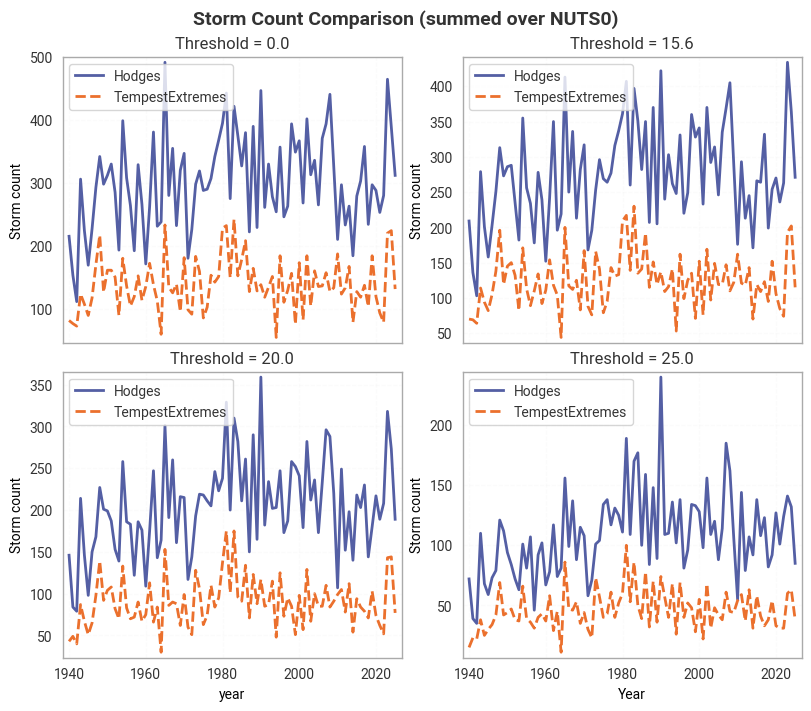

In [52]:
yearly_nuts_sum = compute_yearly_nuts_aggregation(indic_data, "storms_number")

plot_storm_counts(yearly_nuts_sum)

Spatial comparison (% across region where hodges > tempest)

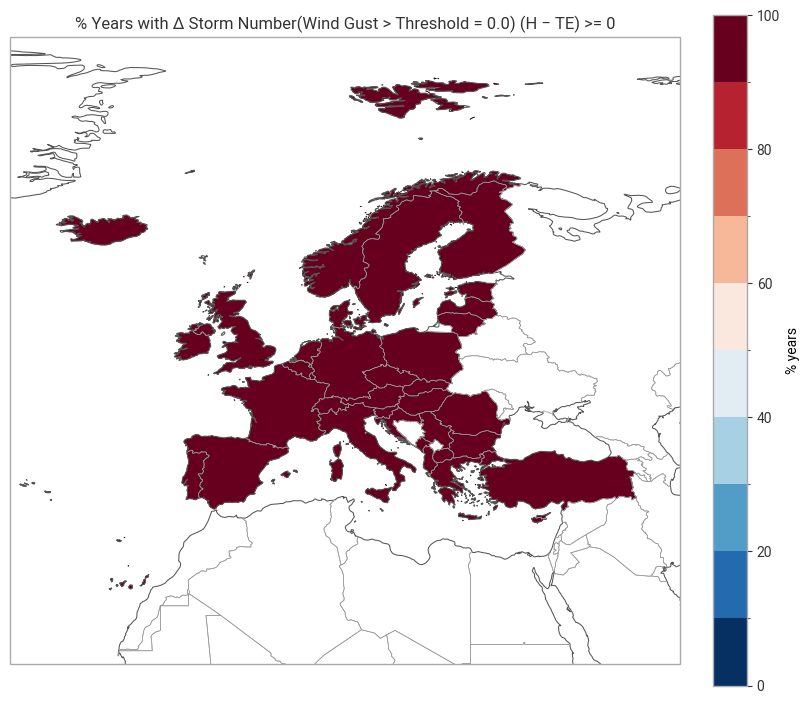

In [53]:
nuts_percentage = computer_percentage_greater_eq(indic_data, nuts_gdf, value_column = "storms_number", threshold = 0.0)

plot_nuts_greater_eq_than_spatial(nuts_percentage[0],
                   title = "% Years with Δ Storm Number(Wind Gust > Threshold = 0.0) (H − TE) >= 0",)

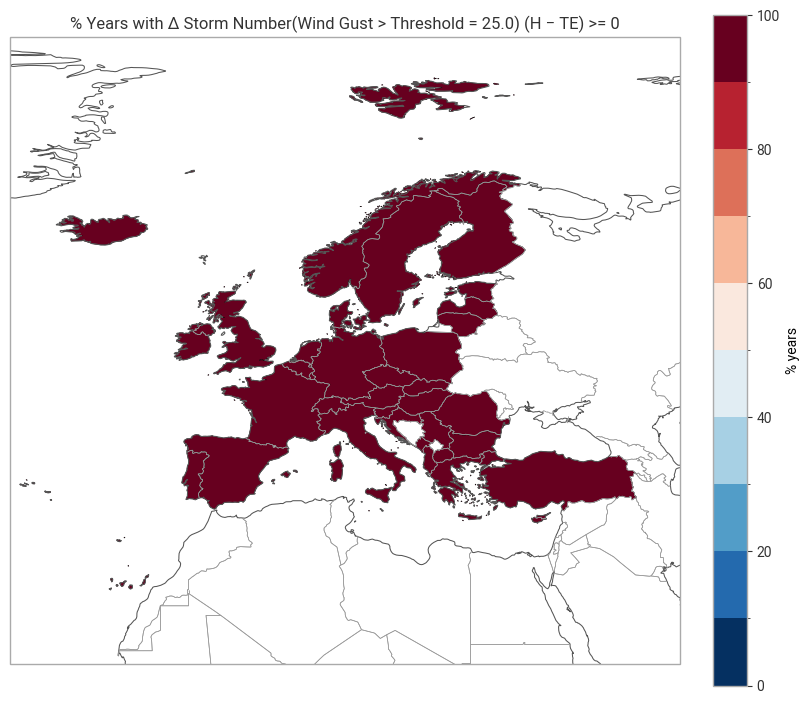

In [54]:
nuts_percentage = computer_percentage_greater_eq(indic_data, nuts_gdf, value_column = "storms_number", threshold = 25.0)

plot_nuts_greater_eq_than_spatial(nuts_percentage[0],
                   title = "% Years with Δ Storm Number(Wind Gust > Threshold = 25.0) (H − TE) >= 0",)

#### Storm Count - from Tracks

Total storm count

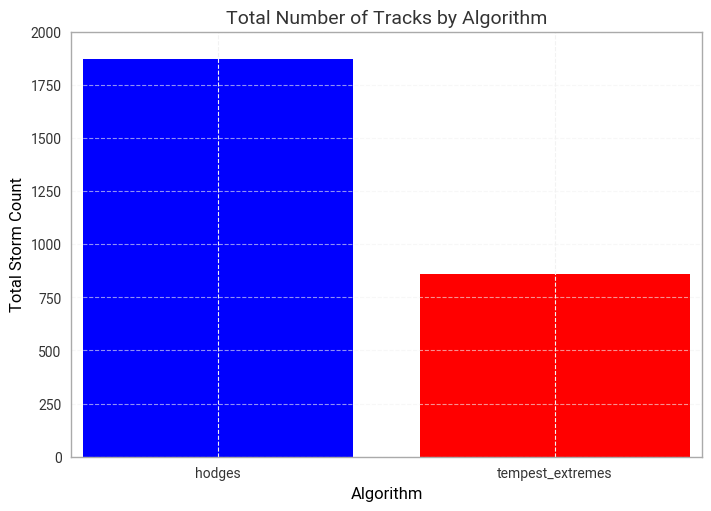

In [55]:
total_track_counts = (
    track_data.reset_index()
    .groupby("algorithm")["id"]
    .nunique()
)

# Define colors explicitly based on algorithm names
colors = [
    "blue" if alg == "hodges" else "red"
    for alg in total_track_counts.index
]

plt.figure(figsize=(7, 5))

plt.bar(total_track_counts.index, total_track_counts, color=colors)

# Labels and title
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Total Storm Count", fontsize=12)
plt.title("Total Number of Tracks by Algorithm", fontsize=14)

# Improve tick appearance
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.ylim([0, 2000])
plt.show()


Monthly storm count

In [56]:
tracks_start_end = get_track_ends(track_data)
tracks_start_end

,algorithm,id,start_time,start_lat,start_lon,end_time,end_lat,end_lon,mean_fg10
0,hodges,1,1940-02-22 00:00:00,63.25,-24.00,1940-02-24 12:00:00,58.75,17.50,12.599429
1,hodges,2,1940-03-12 00:00:00,47.75,-16.75,1940-03-15 06:00:00,53.00,21.75,16.327724
2,hodges,3,1940-03-14 00:00:00,65.25,-5.00,1940-03-15 18:00:00,60.00,0.00,18.169280
3,hodges,4,1940-03-17 12:00:00,48.25,-29.25,1940-03-20 12:00:00,56.75,-4.00,28.481495
4,hodges,5,1940-04-06 00:00:00,59.25,-26.25,1940-04-08 12:00:00,67.00,8.75,23.800018
...,...,...,...,...,...,...,...,...,...
2731,tempest_extremes,858,2024-11-22 12:00:00,50.75,-28.00,2024-11-26 00:00:00,60.00,4.25,19.665087
2732,tempest_extremes,859,2024-12-06 06:00:00,51.25,-23.75,2024-12-07 18:00:00,53.00,4.00,21.266445
2733,tempest_extremes,860,2024-12-17 12:00:00,52.75,-18.00,2024-12-19 18:00:00,64.50,10.00,14.470351
2734,tempest_extremes,861,2024-12-19 12:00:00,64.00,-35.75,2024-12-23 00:00:00,57.00,8.50,20.082300


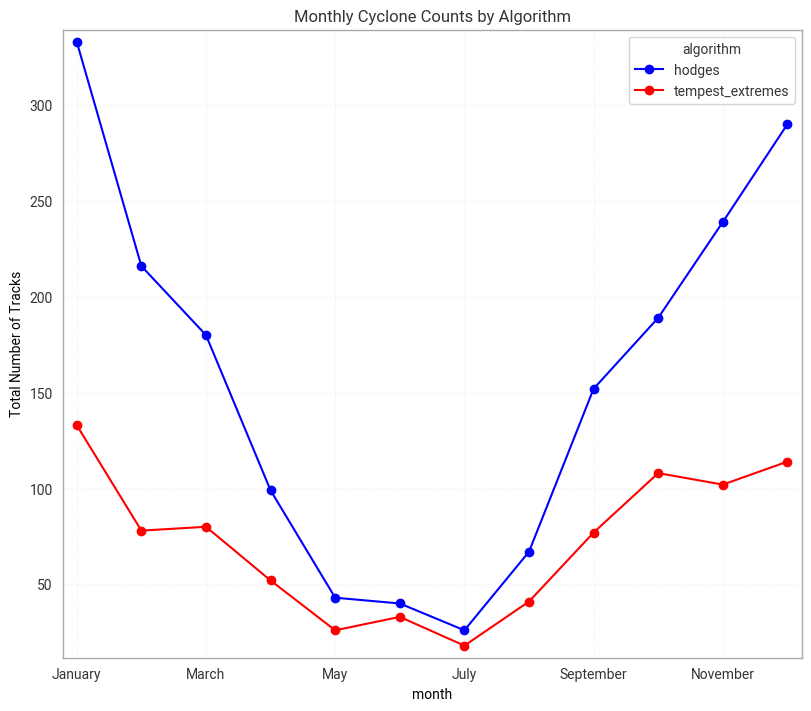

In [57]:
# Extract month by name from start_time
tracks_start_end["month"] = tracks_start_end["start_time"].dt.month_name()

# Count number of tracks per month per algorithm
monthly_counts = (
    tracks_start_end
    .groupby(["algorithm", "month"])
    .size()
    .unstack(fill_value=0)
) 

# Reorder as by default alphabetical!
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_counts = monthly_counts[month_order] # Reorder columns

monthly_counts.T.plot(marker="o", color=colors)

plt.ylabel("Total Number of Tracks")
plt.title("Monthly Cyclone Counts by Algorithm")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Seasonal storm count comparison

In [58]:
tempest_count = count_storms_per_month(track_data, "tempest_extremes") 
hodges_count = count_storms_per_month(track_data, "hodges")

results = {}

results["Algo Comparison"] = compute_fractions(hodges_count, tempest_count)

fraction_table = pd.DataFrame({
    "Winter Fraction (Hodges / Tempest)": [results["Algo Comparison"][0]],
    "Summer Fraction (Hodges / Tempest)": [results["Algo Comparison"][1]],
    "Hodges (Summer / Winter)": [results["Algo Comparison"][2]],
    "Tempest (Summer / Winter)": [results["Algo Comparison"][3]],
}, index=["Fractional Value"])

fraction_table

,Winter Fraction (Hodges / Tempest),Summer Fraction (Hodges / Tempest),Hodges (Summer / Winter),Tempest (Summer / Winter)
Fractional Value,2.457672,1.463918,0.152853,0.256614


Not sure if we still need this if above? But could be good to put some numbers to it.

(section-duration)=
### 4. Duration

#### Mean storm duration (no matchups)

In [59]:
tracks_start_end = get_track_ends(track_data)
mean_track, mean_track_winter, mean_track_summer = track_stats(tracks_start_end)

In [63]:
mean_track["duration (days)"]

algorithm
hodges              2.635005
tempest_extremes    3.383991
Name: duration (days), dtype: float64

In [64]:
mean_track_winter["duration (days)"]

algorithm
hodges              2.458880
tempest_extremes    3.412308
Name: duration (days), dtype: float64

In [65]:
mean_track_summer["duration (days)"]

algorithm
hodges              2.789474
tempest_extremes    3.152174
Name: duration (days), dtype: float64

#### Lifetime distribution (no matchups)

In [ ]:
plot_lifetime_distribution(
    data=[hodges_track_start_end, tempest_track_start_end],
    labels=["hodges", "tempestextremes"],
    bins=np.arange(0, 20, 1),
)

#### Matchups

#### Difference between matchups

(section-intensity)=
### 5. Intensity

#### Mean wind gust - from Indicators

#### Normalsied Storm Severity Index (NSII) - from Indicators

## ℹ️ If you want to know more

### Key resources

Code libraries used:
* [GeoPandas](https://geopandas.org/en/stable/)
* [earthkit](https://github.com/ecmwf/earthkit)
  * [earthkit-data](https://github.com/ecmwf/earthkit-data)
  * [earthkit-plots](https://github.com/ecmwf/earthkit-plots)

### References
